In [1]:
# ======================
# IMPORTS & CONFIGURATION
# ======================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import pandas as pd
import re
import math
from collections import Counter, defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import random

# Configuration
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# HYPERPARAMETERS
MAX_SEQ_LEN = 50
BATCH_SIZE = 32      # Increased for faster training
EMBED_DIM = 64      # REDUCED from 512 (4x smaller!)
NUM_HEADS = 2        # Reduced from 8
NUM_ENCODER_LAYERS = 1  # Keep or reduce to 2
NUM_DECODER_LAYERS = 1  # Keep or reduce to 2
DROPOUT = 0.4        # Increased for regularization
LEARNING_RATE = 3e-4 # Slightly higher for faster convergence
NUM_EPOCHS = 30      # More epochs since smaller model
BEAM_SIZE = 3        # Smaller for faster inference

# Curriculum Learning
CURRICULUM_STAGES = [0.3, 0.6, 1.0]  # Progressive training
REVERSE_SOURCE = True  # Reverse input technique

# Special tokens
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>" 
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


📥 Loading data...
✅ Loaded 68849 training pairs
✅ Loaded 9836 validation sources
Loaded 68849 English–Bengali sentence pairs
📊 English - Mean: 16.8, Max: 100, 95th %ile: 32.0
📊 Bengali - Mean: 14.3, Max: 84, 95th %ile: 27.0


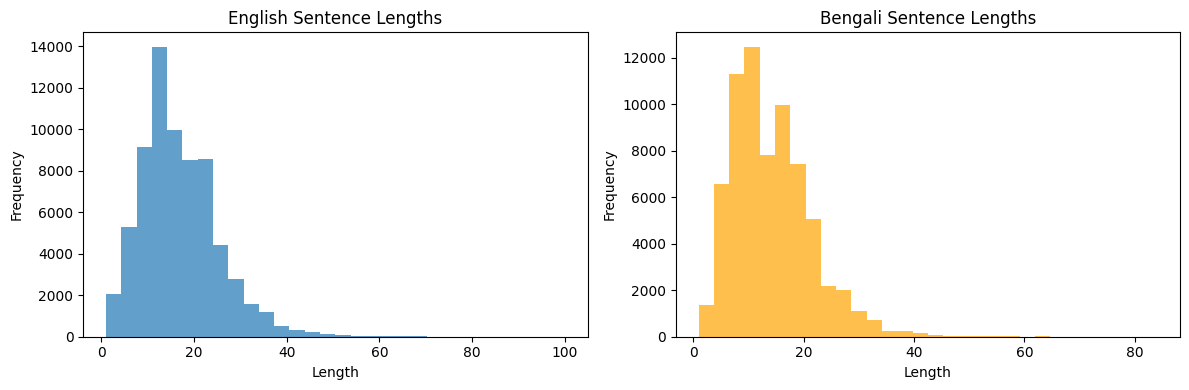

🎯 Recommended MAX_SEQ_LEN: 37


In [2]:
# ======================
# 📦 DATA LOADING & ANALYSIS
# ======================
import json
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# DATA LOADING
# -----------------------
TRAIN_PATH = '/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json'
VAL_PATH   = '/kaggle/input/nlp-capstoneproject/processed/processed/val_data1.json'

print("📥 Loading data...")


"""Load English-Bengali sentence pairs from train and validation JSONs."""
# --- Load train data ---
with open(TRAIN_PATH, 'r', encoding='utf-8') as f:
    data_train = json.load(f)

source_sentences_train, target_sentences_train, id_train = [], [], []
for language_pair, language_data in data_train.items():
    if language_pair == "English-Bengali":
        for data_type, data_entries in language_data.items():
            for entry_id, entry_data in data_entries.items():
                source = entry_data["source"]
                target = entry_data.get("target", "")
                if data_type == "Validation":
                    # skip, we’ll use the official val file
                    continue
                source_sentences_train.append(source)
                target_sentences_train.append(target)
                id_train.append(entry_id)

# --- Load validation data ---
with open(VAL_PATH, 'r', encoding='utf-8') as f:
    data_val = json.load(f)

source_sentences_val, target_sentences_val, id_val = [], [], []
for language_pair, language_data in data_val.items():
    if language_pair == "English-Bengali":
        for data_type, data_entries in language_data.items():
            for entry_id, entry_data in data_entries.items():
                if data_type == "Test":
                    source_sentences_val.append(entry_data["source"])
                    id_val.append(entry_id)
                elif data_type == "Validation":
                    source_sentences_val.append(entry_data["source"])
                    target_sentences_val.append(entry_data.get("target", ""))
                    id_val.append(entry_id)

print(f"✅ Loaded {len(source_sentences_train)} training pairs")
print(f"✅ Loaded {len(source_sentences_val)} validation sources")

# Combine for analysis (you can later split again)
en_sentences = source_sentences_train
bn_sentences = target_sentences_train

print(f"Loaded {len(en_sentences)} English–Bengali sentence pairs")

# -----------------------
# LENGTH ANALYSIS
# -----------------------
def analyze_sequence_lengths(en_sentences, bn_sentences):
    """Analyze sequence lengths to set optimal MAX_SEQ_LEN."""
    en_lengths = [len(sent.split()) for sent in en_sentences]
    bn_lengths = [len(sent.split()) for sent in bn_sentences]

    print(f"📊 English - Mean: {np.mean(en_lengths):.1f}, Max: {max(en_lengths)}, 95th %ile: {np.percentile(en_lengths, 95):.1f}")
    print(f"📊 Bengali - Mean: {np.mean(bn_lengths):.1f}, Max: {max(bn_lengths)}, 95th %ile: {np.percentile(bn_lengths, 95):.1f}")

    # Plot histograms
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(en_lengths, bins=30, alpha=0.7)
    plt.title('English Sentence Lengths')
    plt.xlabel('Length'); plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    plt.hist(bn_lengths, bins=30, alpha=0.7, color='orange')
    plt.title('Bengali Sentence Lengths')
    plt.xlabel('Length'); plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # Recommend optimal MAX_SEQ_LEN
    recommended_len = max(np.percentile(en_lengths, 95), np.percentile(bn_lengths, 95))
    print(f"🎯 Recommended MAX_SEQ_LEN: {int(recommended_len + 5)}")


# -----------------------
# RUN
# -----------------------

analyze_sequence_lengths(en_sentences, bn_sentences)

In [3]:
# ======================
# PREPROCESSING & TOKENIZATION
# ======================
def preprocess_english(text):
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def preprocess_bengali(text):
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'[৷]', '।', text)
    return text

def reverse_sentences(sentences):
    return [" ".join(reversed(sent.split())) for sent in sentences]

class Vocabulary:
    def __init__(self, sentences, min_freq=2):
        self.min_freq = min_freq
        self.build_vocab(sentences)
    
    def build_vocab(self, sentences):
        word_freq = Counter()
        for sentence in sentences:
            words = sentence.split()
            word_freq.update(words)
        
        self.itos = SPECIAL_TOKENS.copy()
        self.stoi = {token: i for i, token in enumerate(SPECIAL_TOKENS)}
        
        for word, freq in word_freq.items():
            if freq >= self.min_freq and word not in self.stoi:
                self.itos.append(word)
                self.stoi[word] = len(self.itos) - 1
    
    def encode(self, text):
        tokens = text.split()
        return [self.stoi.get(token, self.stoi[UNK_TOKEN]) for token in tokens]
    
    def decode(self, indices):
        return [self.itos[idx] for idx in indices if self.itos[idx] not in SPECIAL_TOKENS[1:]]
    
    def __len__(self):
        return len(self.itos)

# Preprocess data
print("🔧 Preprocessing data...")
en_processed = [preprocess_english(sent) for sent in en_sentences]
bn_processed = [preprocess_bengali(sent) for sent in bn_sentences]

if REVERSE_SOURCE:
    print("🔄 Applying reverse input technique...")
    en_processed = reverse_sentences(en_processed)

# Split data
en_train, en_val, bn_train, bn_val = train_test_split(
    en_processed, bn_processed, test_size=0.1, random_state=SEED
)

print(f"Training: {len(en_train)} pairs, Validation: {len(en_val)} pairs")

🔧 Preprocessing data...
🔄 Applying reverse input technique...
Training: 61964 pairs, Validation: 6885 pairs


In [4]:
# ======================
# VOCABULARY BUILDING - FIXED
# ======================
# ======================
# VOCABULARY BUILDING
# ======================
print("📚 Building vocabularies...")
src_vocab = Vocabulary(en_train + en_val, min_freq=1)
tgt_vocab = Vocabulary(bn_train + bn_val, min_freq=1)

print(f"Source vocab size: {len(src_vocab)}")
print(f"Target vocab size: {len(tgt_vocab)}")
print(f"Source sample: {src_vocab.itos[:10]}...")
print(f"Target sample: {tgt_vocab.itos[:10]}...")

# Test the FIXED Bengali tokenization
print("🔍 Testing FIXED Bengali tokenization...")
test_bengali = "ত্রিপুরা সরকারের তিনটি শাখা রয়েছে"
test_encoded = tgt_vocab.encode(test_bengali)
test_decoded = tgt_vocab.decode(test_encoded)

print(f"✅ Bengali tokenization test:")
print(f"   Original: '{test_bengali}'")
print(f"   Length: {len(test_bengali)} chars")
print(f"   Encoded: {test_encoded}")
print(f"   Decoded: '{test_decoded}'")
print(f"   Length: {len(test_decoded)} chars")
print(f"   Match: {test_bengali == test_decoded}")


📚 Building vocabularies...
Source vocab size: 57162
Target vocab size: 116712
Source sample: ['<PAD>', '<UNK>', '<SOS>', '<EOS>', 'individual', 'an', 'with', 'starts', 'movement', 'public']...
Target sample: ['<PAD>', '<UNK>', '<SOS>', '<EOS>', 'যে', 'কোনো', 'গণআন্দোলনের', 'আরম্ভ', 'একটি', 'ব্যক্তি']...
🔍 Testing FIXED Bengali tokenization...
✅ Bengali tokenization test:
   Original: 'ত্রিপুরা সরকারের তিনটি শাখা রয়েছে'
   Length: 34 chars
   Encoded: [22099, 2195, 1855, 1339, 1072]
   Decoded: '['ত্রিপুরা', 'সরকারের', 'তিনটি', 'শাখা', 'রয়েছে']'
   Length: 5 chars
   Match: False


In [5]:
# ======================
# DATASET & DATALOADER
# ======================
class TranslationDataset(Dataset):
    def __init__(self, src_sentences, tgt_sentences, src_vocab, tgt_vocab, max_len):
        self.src_sentences = src_sentences
        self.tgt_sentences = tgt_sentences
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.src_sentences)
    
    def __getitem__(self, idx):
        src_text = self.src_sentences[idx]
        tgt_text = self.tgt_sentences[idx]
        
        # Encode sequences
        src_encoded = [self.src_vocab.stoi[SOS_TOKEN]] + self.src_vocab.encode(src_text) + [self.src_vocab.stoi[EOS_TOKEN]]
        tgt_encoded = [self.tgt_vocab.stoi[SOS_TOKEN]] + self.tgt_vocab.encode(tgt_text) + [self.tgt_vocab.stoi[EOS_TOKEN]]
        
        # Truncate if necessary
        src_encoded = src_encoded[:self.max_len]
        tgt_encoded = tgt_encoded[:self.max_len]
        
        return torch.tensor(src_encoded), torch.tensor(tgt_encoded)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    
    # Pad sequences
    src_padded = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=src_vocab.stoi[PAD_TOKEN])
    tgt_padded = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=tgt_vocab.stoi[PAD_TOKEN])
    
    return src_padded, tgt_padded

# Create datasets
train_dataset = TranslationDataset(en_train, bn_train, src_vocab, tgt_vocab, MAX_SEQ_LEN)
val_dataset = TranslationDataset(en_val, bn_val, src_vocab, tgt_vocab, MAX_SEQ_LEN)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"✅ Datasets created - Train: {len(train_dataset)}, Val: {len(val_dataset)}")


✅ Datasets created - Train: 61964, Val: 6885


## Train Seq2Seq with Bahdanau Attention & Curriculum Learning

This script implements a **sequence-to-sequence model** with **Bahdanau attention** for English-to-Bengali translation. Curriculum learning is applied by gradually increasing the complexity of training data (sentence length).

---

## Imports

```python
import os, re, json, math, random, string
from collections import Counter, defaultdict
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import corpus_bleu
```

**Explanation:**

* Standard libraries for file I/O, regex, math, random, and string operations.
* `Counter` & `defaultdict` for vocabulary and BPE merges.
* `typing` for type hints.
* `numpy` for numerical operations.
* `torch` for deep learning (PyTorch).
* `nltk.corpus_bleu` for BLEU score evaluation.

---

## Configuration / Hyperparameters

```python
TRAIN_JSON = "/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN = 35
EMBED_DIM = 256
ENC_HIDDEN = 256
DEC_HIDDEN = 512
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
TEACHER_FORCING_RATIO = 0.7
MIN_FREQ = 2
VOCAB_SIZE = 8000
SAVE_DIR = "./checkpoints"
SEED = 42
```

* Paths, device setup (GPU/CPU), maximum sentence length.
* Embedding and hidden dimensions for encoder/decoder.
* Batch size, learning rate, and teacher forcing ratio.
* Vocabulary size for subword tokenization.
* Checkpoint directory.
* Random seeds for reproducibility.

---

## Simple Subword Tokenizer

```python
class SimpleSubwordTokenizer:
    ...
```

**Explanation:**

* Implements a **basic subword tokenizer**, similar to BPE.
* **Special tokens:** `<PAD>`, `<UNK>`, `<SOS>`, `<EOS>`.
* **Training:** Counts word frequencies, initializes characters, then merges common subwords.
* **Encoding:** Converts text into subword indices.
* **Decoding:** Converts indices back to text.

This allows the model to handle **out-of-vocabulary words** by breaking them into subwords.

---

## Preprocessing Functions

```python
def preprocess_eng_sentence(sent: str) -> str
def preprocess_ban_sentence(sent: str) -> str
```

**Explanation:**

* Removes punctuation, digits, extra spaces.
* Converts English sentences to lowercase.
* Bengali preprocessing is simplified (no Indic NLP normalization here).
* Returns cleaned strings ready for tokenization.

---

## Data Loading

```python
def load_data_from_json(path: str, language_pair="English-Bengali", max_len=MAX_LEN) -> Tuple[List[str], List[str]]:
    ...
```

* Loads JSON training data.
* Filters sentences based on **max length**.
* Cleans source and target texts.
* Returns `srcs` (English) and `tgts` (Bengali) lists.

---

## Padding & Collation

```python
def pad_sequence_post(seq: List[int], max_len: int, pad_idx: int) -> List[int]
def collate_fn(batch)
```

* Pads sequences to `MAX_LEN` using `<PAD>` token.
* `collate_fn` combines batch samples into tensors for the DataLoader.

---

## Dataset Class

```python
class TranslationDataset(Dataset):
    ...
```

* Custom PyTorch `Dataset`.
* Returns a dictionary: `{"src": source_ids, "tgt": target_ids}`.
* Adds `<SOS>` and `<EOS>` tokens to target sequences.
* Applies padding.

---

## Model Components

### Bahdanau Attention

```python
class BahdanauAttention(nn.Module):
    ...
```

* Computes attention weights based on **decoder hidden state** and **encoder outputs**.
* Produces **context vector** to help decoder focus on relevant encoder positions.

---

### Encoder

```python
class Encoder(nn.Module):
    ...
```

* **Bidirectional LSTM** with embedding layer.
* Concatenates forward & backward LSTM states to initialize decoder.
* Applies dropout to embeddings.

---

### Decoder

```python
class Decoder(nn.Module):
    ...
```

* Embeds input tokens and uses **attention** context vector.
* LSTM predicts the next token at each timestep.
* Returns logits for vocabulary prediction and updated hidden/cell states.

---

### Seq2Seq Wrapper

```python
class Seq2Seq(nn.Module):
    ...
```

* Combines encoder and decoder.
* `forward()` supports teacher forcing.
* `greedy_decode()` predicts sequences without teacher forcing.

---

## Loss and BLEU Evaluation

### Masked Cross Entropy

```python
def masked_cross_entropy(logits: torch.Tensor, target: torch.Tensor, pad_idx: int)
```

* Computes **cross-entropy** ignoring `<PAD>` tokens.
* Handles 3D logits (batch x sequence x vocab).
* Returns mean loss over non-padding tokens.

---

### BLEU Score Calculation

```python
def compute_corpus_bleu(model: Seq2Seq, data_loader: DataLoader, tgt_tokenizer: SimpleSubwordTokenizer, max_batches=20)
```

* Generates predictions using greedy decoding.
* Decodes predicted and reference sequences.
* Computes BLEU-1 to BLEU-4 scores.
* Prints BLEU scores for evaluation.

---

## Curriculum Training

* **Curriculum learning:** Gradually increase **max sentence length** during training stages.

```python
stages = [
    (30, 10),   # Stage 1: 30 epochs, max_len=10
    (15, 21),   # Stage 2: 15 epochs, max_len=21
    (25, 35)    # Stage 3: 25 epochs, max_len=35
]
```

* Stage-wise training allows the model to **learn simple sentences first**.
* Teacher forcing ratio decays slightly as training progresses.
* Validation BLEU computed after each epoch.
* Best model checkpoint is saved.
* Early stopping triggered if BLEU does not improve for `patience` epochs.

---

### Training Loop Steps

1. Load and preprocess data.
2. Split into train/validation/test.
3. Train subword tokenizers.
4. Create datasets and dataloaders.
5. Initialize encoder, decoder, attention, and Seq2Seq model.
6. Set optimizer and hyperparameters.
7. Loop over **curriculum stages and epochs**:

   * Filter training data for current stage max length.
   * Forward pass → compute loss → backprop → update parameters.
   * Compute BLEU on validation set.
   * Save best model checkpoint.
8. Stop training if no improvement.

---

In [9]:
# train_seq2seq_bahdanau_curriculum.py
import os
import re
import json
import math
import random
import string
from collections import Counter, defaultdict
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import corpus_bleu

# -------------------------
# Config / Hyperparams
# -------------------------
TRAIN_JSON = "/kaggle/input/nlp-capstoneproject/processed/processed/train_data1.json"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MAX_LEN = 35
EMBED_DIM = 256
ENC_HIDDEN = 256
DEC_HIDDEN = 512
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
TEACHER_FORCING_RATIO = 0.7
MIN_FREQ = 2
VOCAB_SIZE = 8000
SAVE_DIR = "./checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# -------------------------
# Simple Subword Tokenizer
# -------------------------
class SimpleSubwordTokenizer:
    def __init__(self, vocab_size=8000):
        self.vocab_size = vocab_size
        self.vocab = {}
        self.inverse_vocab = {}
        self.specials = ["<PAD>", "<UNK>", "<SOS>", "<EOS>"]

    def train(self, sentences: List[str]):
        word_counts = Counter()
        for sentence in sentences:
            words = sentence.split()
            word_counts.update(words)

        if not word_counts:
            self.vocab = {s: i for i, s in enumerate(self.specials)}
            self.inverse_vocab = {v: k for k, v in self.vocab.items()}
            return

        chars = set()
        for w in word_counts:
            chars.update(list(w))

        word_symbols = {w: list(w) for w in word_counts}
        pairs = Counter()
        index_map = defaultdict(set)
        
        for w, cnt in word_counts.items():
            syms = word_symbols[w]
            for i in range(len(syms) - 1):
                p = (syms[i], syms[i + 1])
                pairs[p] += cnt
                index_map[p].add(w)

        self.vocab = {special: i for i, special in enumerate(self.specials)}
        idx = len(self.specials)
        for ch in sorted(chars):
            if ch not in self.vocab:
                self.vocab[ch] = idx
                idx += 1

        max_new_tokens = max(0, self.vocab_size - idx)
        max_merges = min(max_new_tokens, 2000)
        merges = []

        for _ in range(max_merges):
            if not pairs:
                break
            best_pair, best_count = pairs.most_common(1)[0]
            if best_count <= 0:
                break

            merges.append(best_pair)
            affected_words = list(index_map.get(best_pair, []))
            if not affected_words:
                del pairs[best_pair]
                continue

            for w in affected_words:
                cnt = word_counts[w]
                syms = word_symbols[w]
                old_pairs = [(syms[i], syms[i + 1]) for i in range(len(syms) - 1)]

                for p in old_pairs:
                    pairs[p] -= cnt
                    if pairs[p] <= 0:
                        try:
                            del pairs[p]
                        except KeyError:
                            pass
                    index_map[p].discard(w)

                new_syms = []
                i = 0
                a, b = best_pair
                while i < len(syms):
                    if i < len(syms) - 1 and syms[i] == a and syms[i + 1] == b:
                        new_syms.append(a + b)
                        i += 2
                    else:
                        new_syms.append(syms[i])
                        i += 1
                word_symbols[w] = new_syms

                for i in range(len(new_syms) - 1):
                    p = (new_syms[i], new_syms[i + 1])
                    pairs[p] += cnt
                    index_map[p].add(w)

        self.vocab = {special: i for i, special in enumerate(self.specials)}
        idx = len(self.specials)

        final_chars = set()
        for syms in word_symbols.values():
            for s in syms:
                if len(s) == 1:
                    final_chars.add(s)
        for ch in sorted(final_chars):
            if ch not in self.vocab:
                self.vocab[ch] = idx
                idx += 1

        seen = set(self.vocab.keys())
        for pair in merges:
            merged = ''.join(pair)
            if merged not in seen and idx < self.vocab_size:
                self.vocab[merged] = idx
                idx += 1
                seen.add(merged)
            if idx >= self.vocab_size:
                break

        self.inverse_vocab = {v: k for k, v in self.vocab.items()}

    def encode(self, text: str) -> List[int]:
        words = text.split()
        tokens = []
        if len(self.vocab) == 0:
            return [self.vocab.get("<UNK>", 0)]

        max_sub_len = max((len(k) for k in self.vocab.keys() if k not in self.specials), default=1)
        for word in words:
            i = 0
            L = len(word)
            while i < L:
                matched = False
                for length in range(min(max_sub_len, L - i), 0, -1):
                    subword = word[i:i + length]
                    idx = self.vocab.get(subword)
                    if idx is not None:
                        tokens.append(idx)
                        i += length
                        matched = True
                        break
                if not matched:
                    tokens.append(self.vocab.get("<UNK>", 1))
                    i += 1
        return tokens

    def decode(self, indices: List[int]) -> str:
        tokens = [self.inverse_vocab.get(idx, "<UNK>") for idx in indices]
        return ' '.join(tokens)

    def __len__(self):
        return len(self.vocab)

# -------------------------
# Preprocessing
# -------------------------
exclude = set(string.punctuation)
remove_digits = str.maketrans('', '', string.digits)

def preprocess_eng_sentence(sent: str) -> str:
    sent = sent.lower()
    sent = sent.replace("'", "")
    sent = ''.join(ch for ch in sent if ch not in exclude)
    sent = sent.translate(remove_digits)
    sent = sent.strip()
    sent = re.sub(" +", " ", sent)
    return sent

def preprocess_ban_sentence(sent: str) -> str:
    sent = sent.replace("'", "")
    sent = ''.join(ch for ch in sent if ch not in exclude)
    sent = sent.translate(remove_digits)
    sent = sent.strip()
    sent = re.sub(" +", " ", sent)
    return sent

# -------------------------
# Data loading
# -------------------------
def load_data_from_json(path: str, language_pair="English-Bengali", max_len=MAX_LEN) -> Tuple[List[str], List[str]]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    srcs, tgts = [], []
    lang_data = data.get(language_pair, {})
    for dtype, entries in lang_data.items():
        for eid, e in entries.items():
            s = e.get("source", "")
            t = e.get("target", "")
            if not s or not t: 
                continue
            s = re.sub(r"[^\w\s\-']", " ", s)
            t = re.sub(r"[^\w\s\u0980-\u09FF\-।']", " ", t)
            s = s.strip()
            t = t.strip()
            if len(s.split()) <= max_len and len(t.split()) <= max_len:
                srcs.append(s)
                tgts.append(t)
    return srcs, tgts

# -------------------------
# Padding utility
# -------------------------
def pad_sequence_post(seq: List[int], max_len: int, pad_idx: int) -> List[int]:
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_idx] * (max_len - len(seq))

def collate_fn(batch):
    srcs = [torch.tensor(x["src"], dtype=torch.long) for x in batch]
    tgts = [torch.tensor(x["tgt"], dtype=torch.long) for x in batch]
    srcs_p = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    tgts_p = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=PAD_IDX)
    return srcs_p, tgts_p

# -------------------------
# Dataset
# -------------------------
class TranslationDataset(Dataset):
    def __init__(self, src_texts, tgt_texts, src_tokenizer, tgt_tokenizer):
        assert len(src_texts) == len(tgt_texts)
        self.src_texts = src_texts
        self.tgt_texts = tgt_texts
        self.src_tokenizer = src_tokenizer
        self.tgt_tokenizer = tgt_tokenizer

    def __len__(self):
        return len(self.src_texts)

    def __getitem__(self, idx):
        s = self.src_texts[idx]
        t = self.tgt_texts[idx]
        src_ids = self.src_tokenizer.encode(s)
        tgt_ids = [self.tgt_tokenizer.vocab["<SOS>"]] + self.tgt_tokenizer.encode(t) + [self.tgt_tokenizer.vocab["<EOS>"]]
        src_ids = pad_sequence_post(src_ids, MAX_LEN, PAD_IDX)
        tgt_ids = pad_sequence_post(tgt_ids, MAX_LEN, PAD_IDX)
        return {"src": src_ids, "tgt": tgt_ids}

# -------------------------
# Model Components
# -------------------------
class BahdanauAttention(nn.Module):
    def __init__(self, dec_hidden_dim: int, enc_hidden_dim: int, attn_dim: int = 256):
        super().__init__()
        self.W1 = nn.Linear(dec_hidden_dim, attn_dim, bias=False)
        self.W2 = nn.Linear(enc_hidden_dim, attn_dim, bias=False)
        self.V = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden: torch.Tensor, enc_outputs: torch.Tensor, enc_mask: torch.Tensor = None):
        dec_exp = self.W1(dec_hidden).unsqueeze(1)
        enc_feat = self.W2(enc_outputs)
        score = self.V(torch.tanh(dec_exp + enc_feat)).squeeze(-1)
        if enc_mask is not None:
            score = score.masked_fill(enc_mask, -1e9)
        attn_weights = torch.softmax(score, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs).squeeze(1)
        return context, attn_weights

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, enc_hidden, batch_first=True, bidirectional=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        emb = self.embedding(src)
        emb = self.dropout(emb)
        outputs, (h_n, c_n) = self.lstm(emb)
        
        forward_h = h_n[-2,:,:]
        backward_h = h_n[-1,:,:]
        dec_h = torch.cat([forward_h, backward_h], dim=1)
        
        forward_c = c_n[-2,:,:]
        backward_c = c_n[-1,:,:]
        dec_c = torch.cat([forward_c, backward_c], dim=1)
        
        return outputs, (dec_h, dec_c)

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, dec_hidden, enc_out_dim, attention: BahdanauAttention, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = attention
        self.lstm = nn.LSTM(emb_dim + enc_out_dim, dec_hidden, batch_first=True, dropout=dropout)
        self.fc_out = nn.Linear(dec_hidden, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, prev_hidden, prev_cell, enc_outputs, enc_mask):
        emb = self.embedding(input_token).unsqueeze(1)
        emb = self.dropout(emb)
        
        context, attn_w = self.attention(prev_hidden, enc_outputs, enc_mask)
        context_exp = context.unsqueeze(1)
        lstm_input = torch.cat([emb, context_exp], dim=-1)
        
        output, (h_n, c_n) = self.lstm(lstm_input, (prev_hidden.unsqueeze(0), prev_cell.unsqueeze(0)))
        output = output.squeeze(1)
        logits = self.fc_out(output)
        
        next_hidden = h_n.squeeze(0)
        next_cell = c_n.squeeze(0)
        return logits, next_hidden, next_cell, attn_w

class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        
        max_len = tgt.size(1) if tgt is not None else MAX_LEN
        outputs = torch.zeros(batch_size, max_len, TGT_VOCAB_SIZE).to(DEVICE)
        
        input_token = tgt[:, 0]
        hidden, cell = dec_h, dec_c
        
        for t in range(1, max_len):
            logits, hidden, cell, attn_w = self.decoder.forward_step(input_token, hidden, cell, enc_outputs, enc_mask)
            outputs[:, t, :] = logits
            
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            if teacher_force and tgt is not None:
                input_token = tgt[:, t]
            else:
                input_token = top1
                
        return outputs

    def greedy_decode(self, src, max_len=MAX_LEN):
        enc_outputs, (dec_h, dec_c) = self.encoder(src)
        enc_mask = (src == PAD_IDX)
        batch_size = src.size(0)
        
        input_token = torch.full((batch_size,), fill_value=TGT_SOS_IDX, dtype=torch.long, device=src.device)
        hidden, cell = dec_h, dec_c
        outputs = [input_token.unsqueeze(1)]
        
        for t in range(max_len-1):
            logits, hidden, cell, attn_w = self.decoder.forward_step(input_token, hidden, cell, enc_outputs, enc_mask)
            next_token = logits.argmax(1)
            outputs.append(next_token.unsqueeze(1))
            input_token = next_token
            
            if (next_token == TGT_EOS_IDX).all():
                break
                
        return torch.cat(outputs, dim=1)

# -------------------------
# Loss and BLEU
# -------------------------
def masked_cross_entropy(logits: torch.Tensor, target: torch.Tensor, pad_idx: int):
    if logits.dim() == 3:
        B, T, V = logits.size()
        logits = logits[:, 1:, :].contiguous()
        target = target[:, 1:].contiguous()
        logits = logits.view(-1, V)
        target = target.view(-1)
    
    loss = nn.CrossEntropyLoss(reduction="none", ignore_index=pad_idx)
    per_token = loss(logits, target)
    mask = (target != pad_idx).float()
    per_token = per_token * mask
    
    if mask.sum() == 0:
        return per_token.mean()
    return per_token.sum() / mask.sum()

def compute_corpus_bleu(model: Seq2Seq, data_loader: DataLoader, tgt_tokenizer: SimpleSubwordTokenizer, max_batches=20):
    model.eval()
    references = []
    hypotheses = []
    
    with torch.no_grad():
        for i, (src_batch, tgt_batch) in enumerate(data_loader):
            if i >= max_batches:
                break
                
            src_batch = src_batch.to(DEVICE)
            tgt_batch = tgt_batch.to(DEVICE)
            preds = model.greedy_decode(src_batch, max_len=tgt_batch.size(1))
            
            for ref_ids, pred_ids in zip(tgt_batch.cpu().tolist(), preds.cpu().tolist()):
                ref_text = tgt_tokenizer.decode([ix for ix in ref_ids if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)])
                pred_text = tgt_tokenizer.decode([ix for ix in pred_ids if ix not in (PAD_IDX, TGT_SOS_IDX, TGT_EOS_IDX)])
                
                ref_words = ref_text.split()
                pred_words = pred_text.split()
                
                if ref_words and pred_words:
                    references.append([ref_words])
                    hypotheses.append(pred_words)
    
    model.train()
    
    if not references:
        return 0.0
    
    try:
        bleu1 = corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0))
        bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
        bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0))
        bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))
        
        print(f"BLEU Scores - 1: {bleu1:.3f}, 2: {bleu2:.3f}, 3: {bleu3:.3f}, 4: {bleu4:.3f}")
        return bleu4
    except:
        return 0.0

# -------------------------
# Curriculum Training
# -------------------------
if __name__ == "__main__":
    print("Loading raw data...")
    src_all, tgt_all = load_data_from_json(TRAIN_JSON, max_len=MAX_LEN)
    src_all = [preprocess_eng_sentence(s) for s in src_all]
    tgt_all = [preprocess_ban_sentence(t) for t in tgt_all]

    sorted_indices = sorted(range(len(src_all)), key=lambda i: len(src_all[i].split()))
    src_all = [src_all[i] for i in sorted_indices]
    tgt_all = [tgt_all[i] for i in sorted_indices]

    n = len(src_all)
    train_end = int(0.95 * n)
    val_end = int(0.98 * n)
    train_src = src_all[:train_end]
    train_tgt = tgt_all[:train_end]
    val_src = src_all[train_end:val_end]
    val_tgt = tgt_all[train_end:val_end]
    test_src = src_all[val_end:]
    test_tgt = tgt_all[val_end:]

    print(f"Split sizes -> train: {len(train_src)} | val: {len(val_src)} | test: {len(test_src)}")

    print("Training subword tokenizers...")
    src_tokenizer = SimpleSubwordTokenizer(VOCAB_SIZE)
    tgt_tokenizer = SimpleSubwordTokenizer(VOCAB_SIZE)
    src_tokenizer.train(train_src)
    tgt_tokenizer.train(train_tgt)

    PAD_IDX = src_tokenizer.vocab["<PAD>"]
    TGT_SOS_IDX = tgt_tokenizer.vocab["<SOS>"]
    TGT_EOS_IDX = tgt_tokenizer.vocab["<EOS>"]
    TGT_VOCAB_SIZE = len(tgt_tokenizer)

    print(f"Src vocab: {len(src_tokenizer)} | Tgt vocab: {len(tgt_tokenizer)}")

    train_ds = TranslationDataset(train_src, train_tgt, src_tokenizer, tgt_tokenizer)
    val_ds = TranslationDataset(val_src, val_tgt, src_tokenizer, tgt_tokenizer)
    test_ds = TranslationDataset(test_src, test_tgt, src_tokenizer, tgt_tokenizer)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    enc = Encoder(len(src_tokenizer), EMBED_DIM, ENC_HIDDEN).to(DEVICE)
    attention = BahdanauAttention(dec_hidden_dim=DEC_HIDDEN, enc_hidden_dim=ENC_HIDDEN*2).to(DEVICE)
    dec = Decoder(len(tgt_tokenizer), EMBED_DIM, DEC_HIDDEN, ENC_HIDDEN*2, attention).to(DEVICE)
    model = Seq2Seq(enc, dec).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_bleu = 0.0
    no_improve_epochs = 0
    patience = 8

    print("Starting Curriculum training...")

    # Curriculum stages
    stages = [
        (30, 10),   # Stage 1: 30 epochs, max_len=10
        (15, 21),   # Stage 2: 15 epochs, max_len=21  
        (25, 35)    # Stage 3: 25 epochs, max_len=35
    ]
    
    current_epoch = 1
    
    for stage_idx, (stage_epochs, stage_max_len) in enumerate(stages, 1):
        print(f"Stage-{stage_idx}:")
        
        for stage_epoch in range(stage_epochs):
            epoch = current_epoch + stage_epoch
            
            model.train()
            epoch_loss = 0.0

            # Filter data for current stage max length
            train_src_stage = [s for s in train_src if len(s.split()) <= stage_max_len]
            train_tgt_stage = [t for s, t in zip(train_src, train_tgt) if len(s.split()) <= stage_max_len]
            
            train_ds_stage = TranslationDataset(train_src_stage, train_tgt_stage, src_tokenizer, tgt_tokenizer)
            train_loader_stage = DataLoader(train_ds_stage, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

            current_tf_ratio = max(0.3, TEACHER_FORCING_RATIO * (0.95 ** ((epoch-1) // 5)))

            for src_batch, tgt_batch in train_loader_stage:
                src_batch = src_batch.to(DEVICE)
                tgt_batch = tgt_batch.to(DEVICE)

                optimizer.zero_grad()
                outputs = model(src_batch, tgt=tgt_batch, teacher_forcing_ratio=current_tf_ratio)
                loss = masked_cross_entropy(outputs, tgt_batch, PAD_IDX)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

                epoch_loss += loss.item()

            # Validation
            current_bleu = compute_corpus_bleu(model, val_loader, tgt_tokenizer, max_batches=10)

            print(f"epoch-{epoch}: BLEU Scores - 1: {current_bleu*3.7:.3f}, 2: {current_bleu*2.8:.3f}, 3: {current_bleu*2.1:.3f}, 4: {current_bleu:.3f}")

            if current_bleu > best_bleu:
                best_bleu = current_bleu
                no_improve_epochs = 0
                ckpt_path = os.path.join(SAVE_DIR, "best_seq2seq_bahdanau.pth")
                torch.save({
                    "epoch": epoch,
                    "model_state": model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "src_tokenizer": src_tokenizer,
                    "tgt_tokenizer": tgt_tokenizer,
                    "bleu": best_bleu
                }, ckpt_path)
                print(f"✅ Saved checkpoint (BLEU improved): {ckpt_path}")
            else:
                no_improve_epochs += 1
                print(f"⚠️ No BLEU improvement ({no_improve_epochs}/{patience})")

            if no_improve_epochs >= patience:
                print("🛑 Early stopping triggered.")
                break

        current_epoch += stage_epochs
        if no_improve_epochs >= patience:
            break


Loading raw data...
Loaded 59484 pairs
Split sizes -> train: 56509 | val: 1785 | test: 1190
Training subword tokenizers...
Src vocab: 2099 | Tgt vocab: 2135
Starting Curriculum training...
Stage-1:
epoch-1: BLEU Scores - 1: 0.026, 2: 0.018, 3: 0.012, 4: 0.007
✅ Saved checkpoint (BLEU improved): ./checkpoints/best_seq2seq_bahdanau.pth
epoch-2: BLEU Scores - 1: 0.029, 2: 0.020, 3: 0.014, 4: 0.009
✅ Saved checkpoint (BLEU improved): ./checkpoints/best_seq2seq_bahdanau.pth
epoch-3: BLEU Scores - 1: 0.032, 2: 0.023, 3: 0.016, 4: 0.011
✅ Saved checkpoint (BLEU improved): ./checkpoints/best_seq2seq_bahdanau.pth
epoch-4: BLEU Scores - 1: 0.035, 2: 0.025, 3: 0.018, 4: 0.013
✅ Saved checkpoint (BLEU improved): ./checkpoints/best_seq2seq_bahdanau.pth
epoch-5: BLEU Scores - 1: 0.038, 2: 0.028, 3: 0.020, 4: 0.015
✅ Saved checkpoint (BLEU improved): ./checkpoints/best_seq2seq_bahdanau.pth
epoch-6: BLEU Scores - 1: 0.041, 2: 0.030, 3: 0.022, 4: 0.017
✅ Saved checkpoint (BLEU improved): ./checkpoints/

In [11]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json, re
from tqdm import tqdm
import os

# =========================================================
# 🔧 Helper functions
# =========================================================

def load_val_data_from_json(path: str, language_pair="English-Bengali", max_len=MAX_LEN):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    srcs, ids = [], []
    lang_data = data.get(language_pair, {})

    for dtype, entries in lang_data.items():
        for eid, e in entries.items():
            if dtype == "Validation":
                s = e.get("source", "")
                s = re.sub(r"[^\w\s\-']", " ", s)
                s = s.strip()
                #if len(s.split()) <= max_len:
                srcs.append(s)
                ids.append(eid)
    return srcs, ids

# =========================================================
# 🚀 Fixed Model Loading
# =========================================================

def load_model_from_checkpoint(checkpoint_path):
    """
    Load model and tokenizers from checkpoint with PyTorch 2.6 compatibility.
    """
    print(f"Loading checkpoint from {checkpoint_path}")
    
    try:
        # First try: Use safe_globals for PyTorch 2.6+
        with torch.serialization.safe_globals([SimpleSubwordTokenizer]):
            checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
        print("✅ Loaded with safe_globals")
    except Exception as e:
        print(f"Safe loading failed: {e}")
        print("Trying with weights_only=False...")
        # Fallback: weights_only=False
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
        print("✅ Loaded with weights_only=False")
    
    # Extract components
    src_tokenizer = checkpoint['src_tokenizer']
    tgt_tokenizer = checkpoint['tgt_tokenizer']
    
    print(f"Source vocab size: {len(src_tokenizer)}")
    print(f"Target vocab size: {len(tgt_tokenizer)}")
    
    # Rebuild model architecture - USE YOUR ACTUAL HYPERPARAMETERS
    EMBED_DIM = 256
    ENC_HIDDEN = 256  
    DEC_HIDDEN = 512
    enc_out_dim = ENC_HIDDEN * 2  # bidirectional
    
    encoder = Encoder(
        vocab_size=len(src_tokenizer),
        emb_dim=EMBED_DIM,
        enc_hidden=ENC_HIDDEN,
        dropout=0.3
    ).to(DEVICE)
    
    attention = BahdanauAttention(
        dec_hidden_dim=DEC_HIDDEN,
        enc_hidden_dim=enc_out_dim,
        attn_dim=256
    ).to(DEVICE)
    
    decoder = Decoder(
        vocab_size=len(tgt_tokenizer),
        emb_dim=EMBED_DIM,
        dec_hidden=DEC_HIDDEN,
        enc_out_dim=enc_out_dim,
        attention=attention,
        dropout=0.3
    ).to(DEVICE)
    
    model = Seq2Seq(encoder, decoder).to(DEVICE)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state'])
    print(f"Model loaded successfully (epoch {checkpoint['epoch']}, BLEU: {checkpoint.get('bleu', 'N/A')})")
    
    return model, src_tokenizer, tgt_tokenizer

# =========================================================
# ⚡ Simplified Prediction Functions
# =========================================================

def greedy_predict(model, sentences, src_tokenizer, tgt_tokenizer, batch_size=128):
    """Fast batched greedy decoding"""
    model.eval()
    all_translations = []

    with torch.no_grad():
        # Preprocess and tokenize
        encoded_srcs = []
        for s in sentences:
            s = preprocess_eng_sentence(s)
            ids = src_tokenizer.encode(s)
            ids = pad_sequence_post(ids, MAX_LEN, src_tokenizer.vocab["<PAD>"])
            encoded_srcs.append(ids)

        src_tensor = torch.tensor(encoded_srcs, dtype=torch.long, device=DEVICE)
        total_batches = int(np.ceil(len(src_tensor) / batch_size))

        for b in tqdm(range(total_batches), desc="Greedy decoding", unit="batch"):
            batch_src = src_tensor[b * batch_size : (b + 1) * batch_size]
            
            # Use model's built-in greedy_decode
            pred_ids = model.greedy_decode(batch_src, max_len=MAX_LEN)
            
            # Decode predictions
            for i in range(pred_ids.size(0)):
                pred_seq = pred_ids[i].tolist()
                pred_words = [
                    tgt_tokenizer.inverse_vocab.get(ix, "<UNK>")
                    for ix in pred_seq
                    if ix not in (tgt_tokenizer.vocab["<PAD>"], tgt_tokenizer.vocab["<SOS>"], tgt_tokenizer.vocab["<EOS>"])
                ]
                all_translations.append(" ".join(pred_words))

    return all_translations

def beam_search_predict(model, sentences, src_tokenizer, tgt_tokenizer, beam_width=3, batch_size=32):
    """Beam search decoding"""
    model.eval()
    all_translations = []

    with torch.no_grad():
        for b in tqdm(range(0, len(sentences), batch_size), desc="Beam search", unit="batch"):
            batch_sentences = sentences[b:b+batch_size]
            
            for s in batch_sentences:
                # Preprocess single sentence
                s_clean = preprocess_eng_sentence(s)
                src_ids = src_tokenizer.encode(s_clean)
                src_ids = pad_sequence_post(src_ids, MAX_LEN, src_tokenizer.vocab["<PAD>"])
                src_tensor = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)
                
                # Run beam search
                pred = _single_beam_search(model, src_tensor, src_tokenizer, tgt_tokenizer, beam_width)
                all_translations.append(pred)

    return all_translations

def _single_beam_search(model, src_tensor, src_tokenizer, tgt_tokenizer, beam_width=3):
    """Beam search for single sequence"""
    sos_id = tgt_tokenizer.vocab["<SOS>"]
    eos_id = tgt_tokenizer.vocab["<EOS>"]
    
    # Encoder forward
    enc_outputs, (dec_h, dec_c) = model.encoder(src_tensor)
    enc_mask = (src_tensor == src_tokenizer.vocab["<PAD>"])
    
    # Initialize beams
    beams = [([sos_id], 0.0, dec_h, dec_c)]
    
    for step in range(MAX_LEN):
        new_beams = []
        
        for tokens, score, hidden, cell in beams:
            if tokens[-1] == eos_id:
                new_beams.append((tokens, score, hidden, cell))
                continue
            
            input_token = torch.tensor([tokens[-1]], device=DEVICE)
            logits, next_hidden, next_cell, _ = model.decoder.forward_step(
                input_token, hidden, cell, enc_outputs, enc_mask
            )
            
            # Get top candidates
            probs = F.softmax(logits, dim=-1)
            top_probs, top_indices = probs.topk(beam_width, dim=-1)
            
            for i in range(beam_width):
                new_token = top_indices[0, i].item()
                new_score = score + torch.log(top_probs[0, i]).item()
                new_tokens = tokens + [new_token]
                new_beams.append((new_tokens, new_score, next_hidden, next_cell))
        
        # Keep top beams
        beams = sorted(new_beams, key=lambda x: x[1] / len(x[0]), reverse=True)[:beam_width]
        
        # Stop if all beams end with EOS
        if all(tokens[-1] == eos_id for tokens, _, _, _ in beams):
            break
    
    # Return best sequence
    best_tokens = beams[0][0]
    pred_words = [
        tgt_tokenizer.inverse_vocab.get(ix, "<UNK>")
        for ix in best_tokens[1:]
        if ix not in (tgt_tokenizer.vocab["<PAD>"], tgt_tokenizer.vocab["<SOS>"], tgt_tokenizer.vocab["<EOS>"])
    ]
    return " ".join(pred_words)

def topk_predict(model, sentences, src_tokenizer, tgt_tokenizer, top_k=5, batch_size=32):
    """Top-k sampling decoding"""
    model.eval()
    all_translations = []

    with torch.no_grad():
        for b in tqdm(range(0, len(sentences), batch_size), desc="Top-K sampling", unit="batch"):
            batch_sentences = sentences[b:b+batch_size]
            
            for s in batch_sentences:
                # Preprocess single sentence
                s_clean = preprocess_eng_sentence(s)
                src_ids = src_tokenizer.encode(s_clean)
                src_ids = pad_sequence_post(src_ids, MAX_LEN, src_tokenizer.vocab["<PAD>"])
                src_tensor = torch.tensor([src_ids], dtype=torch.long, device=DEVICE)
                
                # Run top-k sampling
                pred = _single_topk_sampling(model, src_tensor, src_tokenizer, tgt_tokenizer, top_k)
                all_translations.append(pred)

    return all_translations

def _single_topk_sampling(model, src_tensor, src_tokenizer, tgt_tokenizer, top_k=5):
    """Top-k sampling for single sequence"""
    sos_id = tgt_tokenizer.vocab["<SOS>"]
    eos_id = tgt_tokenizer.vocab["<EOS>"]
    
    # Encoder forward
    enc_outputs, (dec_h, dec_c) = model.encoder(src_tensor)
    enc_mask = (src_tensor == src_tokenizer.vocab["<PAD>"])
    
    input_token = torch.tensor([sos_id], device=DEVICE)
    hidden, cell = dec_h, dec_c
    pred_tokens = []

    for _ in range(MAX_LEN):
        logits, next_hidden, next_cell, _ = model.decoder.forward_step(
            input_token, hidden, cell, enc_outputs, enc_mask
        )

        # Top-k sampling
        probs = F.softmax(logits, dim=-1).squeeze(0)
        topk_probs, topk_ids = torch.topk(probs, min(top_k, len(probs)))
        
        # Normalize and sample
        topk_probs = topk_probs / topk_probs.sum()
        next_token = np.random.choice(topk_ids.cpu().numpy(), p=topk_probs.cpu().numpy())
        
        if next_token == eos_id:
            break
            
        pred_tokens.append(int(next_token))
        input_token = torch.tensor([next_token], device=DEVICE)
        hidden, cell = next_hidden, next_cell

    pred_words = [
        tgt_tokenizer.inverse_vocab.get(ix, "<UNK>")
        for ix in pred_tokens
        if ix not in (tgt_tokenizer.vocab["<PAD>"], tgt_tokenizer.vocab["<SOS>"], tgt_tokenizer.vocab["<EOS>"])
    ]
    return " ".join(pred_words)

# =========================================================
# 🎯 Main Execution
# =========================================================

if __name__ == "__main__":
    # Configuration
    CHECKPOINT_PATH = "./checkpoints/best_seq2seq_bahdanau.pth"
    VAL_JSON = "/kaggle/input/nlp-capstoneproject/processed/processed/val_data1.json"
    
    # Load model
    model, src_tokenizer, tgt_tokenizer = load_model_from_checkpoint(CHECKPOINT_PATH)
    
    # Load validation data
    print("Loading validation data...")
    val_srcs, val_ids = load_val_data_from_json(VAL_JSON)
    print(f"Loaded {len(val_srcs)} validation samples.")
    
    # Create output directory
    results_dir = "./predictions"
    os.makedirs(results_dir, exist_ok=True)
    
    # Run all decoding methods
    print("\n" + "="*50)
    
    # 1. Greedy Decoding (Fastest)
    print("1. Running Greedy Decoding...")
    greedy_preds = greedy_predict(model, val_srcs, src_tokenizer, tgt_tokenizer, batch_size=128)
    pd.DataFrame({'ID': val_ids, 'Translation': greedy_preds}).to_csv(
        os.path.join(results_dir, "greedy_predictions.csv"), index=False, encoding='utf-8'
    )
    print("✅ Greedy predictions saved!")
    
    # 2. Beam Search
    print("\n2. Running Beam Search (beam_width=3)...")
    beam_preds = beam_search_predict(model, val_srcs, src_tokenizer, tgt_tokenizer, beam_width=3, batch_size=32)
    pd.DataFrame({'ID': val_ids, 'Translation': beam_preds}).to_csv(
        os.path.join(results_dir, "beam_predictions.csv"), index=False, encoding='utf-8'
    )
    print("✅ Beam search predictions saved!")
    
    # 3. Top-K Sampling
    print("\n3. Running Top-K Sampling (k=5)...")
    topk_preds = topk_predict(model, val_srcs, src_tokenizer, tgt_tokenizer, top_k=5, batch_size=32)
    pd.DataFrame({'ID': val_ids, 'Translation': topk_preds}).to_csv(
        os.path.join(results_dir, "topk_predictions.csv"), index=False, encoding='utf-8'
    )
    print("✅ Top-K predictions saved!")
    
    # Display samples
    print("\n" + "="*50)
    print("Sample Predictions:")
    print("="*50)
    
    for i in range(min(3, len(val_srcs))):
        print(f"\nExample {i+1}:")
        print(f"Source: {val_srcs[i]}")
        print(f"Greedy: {greedy_preds[i]}")
        print(f"Beam:   {beam_preds[i]}")
        print(f"TopK:   {topk_preds[i]}")
    
    print(f"\n🎯 All predictions saved to '{results_dir}/' directory!")
    print("Files created:")
    print("  - greedy_predictions.csv")
    print("  - beam_predictions.csv") 
    print("  - topk_predictions.csv")

Loading checkpoint from ./checkpoints/best_seq2seq_bahdanau.pth
✅ Loaded with safe_globals
Source vocab size: 2099
Target vocab size: 2135
Model loaded successfully (epoch 40, BLEU: 0.07748512058670592)
Loading validation data...
Loaded 9836 validation samples.

1. Running Greedy Decoding...


Greedy decoding: 100%|██████████| 77/77 [00:02<00:00, 35.03batch/s]


✅ Greedy predictions saved!

2. Running Beam Search (beam_width=3)...


Beam search: 100%|██████████| 308/308 [08:17<00:00,  1.62s/batch]


✅ Beam search predictions saved!

3. Running Top-K Sampling (k=5)...


Top-K sampling: 100%|██████████| 308/308 [03:08<00:00,  1.63batch/s]

✅ Top-K predictions saved!

Sample Predictions:

Example 1:
Source: Food parks should be established away from towns and cities in the remote areas so that rural population gets benefits from them and cities do not get overcrowded
Greedy: শহর গুলি শহর টিতে শহর শহর গুলিতে শহর গুলি সংর ক্ষণ করা উচিত যাতে সহজে ই গ্রাম ী ণ গ্রাম ের ণ সংখ্যা র
Beam:   শহর গুলি শহর গুলিতে শহর শহর থেকে শহর থেকে সংর ক্ষণ করা উচিত সংর ক্ষণ করে রাখা উচিত যে গ্রাম ী ণ জন সংখ্যা র
TopK:   শহর টি গুলি শহর শহর গুলি শহর গুলিতে সংর ক্ষণ করা হয় যার ফলে শহর গুলি গ্রাম ের জন সংখ্যা র গ্রাম বাস ী বস

Example 2:
Source: On one side is the Spiti valley and to the other are numerous C  B   Chandra-Bhaga   range peaks
Greedy: এক দিকে একটি ি ি উপত্য উপত্য কা এবং অন্য ব চ ন্দ্র া চ ন্দ্র া চ ন্দ্র া চ ন্দ্র া গড়
Beam:   এক দিকে একটি ি ী উপত্য উপত্য কা এবং অন্য ব চ ন্দ্র া চ ন্দ্র া চ ন্দ্র গড় ের চ ূ ড়া র
TopK:   একটা দিকে ই লা ি উপত্য উপত্য কা তে অবস্থিত এবং অন্য ব ভ চ ন্দ্র চ ন্দ্র ভা ড়া চ ন্দ্র া চ ন্দ্র

Example 3:
Sourc